# Fake Audio Detection: Fair Test

A stricter version of Part 2 that removes the easy shortcuts the classifier could use.

**Data** (built by `prepare_fair_test.py`):
- `data/fair/cloned_audio`: 300 SV2TTS clones of TIMIT speakers (from `clone_speakers.py`)
- `data/fair/real_audio`: one real TIMIT recording from each of the **same 300 speakers**

**Controls:**
- Real and cloned audio come from the same corpus and the same voices, so the model can't separate them by recording conditions or speaker
- Leading/trailing silence is trimmed identically from both classes (removing the 1s pad `synthesize_audio` adds to clones)
- Splits are by speaker, so no voice appears in both training and test data
- Besides the single train/val/test split used in the original notebook, 5-fold speaker-grouped cross-validation gives a more reliable estimate than a 60-clip test set

Features and model are unchanged from Part 2.

In [1]:
import os
import pandas as pd
import numpy as np
import functions

import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.metrics import accuracy_score, f1_score

import tensorflow as tf

tf.random.set_seed(42)
np.random.seed(42)

2026-09-27 16:20:53.125806: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


#### Dataset preparation
Each speaker contributes one cloned (y=0) and one real (y=1) recording.

In [2]:
rows = []
for folder, label in [('data/fair/cloned_audio', 0), ('data/fair/real_audio', 1)]:
    for f in sorted(os.listdir(folder)):
        rows.append({'files': f'{folder}/{f}', 'y': label, 'speaker': f[:-4]})

df = pd.DataFrame(rows)
print(df.shape)
print(df.y.value_counts())
print('Speakers:', df.speaker.nunique())
df.head()

(600, 3)
y
0    300
1    300
Name: count, dtype: int64
Speakers: 300


,files,y,speaker
0,data/fair/cloned_audio/FADG0.wav,0,FADG0
1,data/fair/cloned_audio/FAEM0.wav,0,FAEM0
2,data/fair/cloned_audio/FAJW0.wav,0,FAJW0
3,data/fair/cloned_audio/FAKS0.wav,0,FAKS0
4,data/fair/cloned_audio/FALK0.wav,0,FALK0


Features are extracted once for all 600 files and reused by every split.

In [3]:
features = functions.extract_features(df.files)
X_all = functions.concat_features(features)
y_all = df.y.values
groups = df.speaker.values
print(X_all.shape)

(600, 193)


In [4]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(50, activation='relu', input_shape=(193,)),
        tf.keras.layers.Dense(50, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model


def speaker_split(idx, test_size, seed=42):
    """Splits row indices so each speaker's recordings end up on one side."""
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(gss.split(idx, groups=groups[idx]))
    return idx[a], idx[b]

#### Single split (as in the original notebook)
10% of speakers for testing, 10% of the rest for validation.

In [5]:
train_idx, test_idx = speaker_split(np.arange(len(df)), test_size=0.1)
train_idx, val_idx = speaker_split(train_idx, test_size=0.1)

for name, idx in [('train', train_idx), ('val', val_idx), ('test', test_idx)]:
    print(f"{name}: {len(idx)} files, {len(set(groups[idx]))} speakers, labels {np.bincount(y_all[idx])}")

assert not set(groups[train_idx]) & set(groups[test_idx])

train: 486 files, 243 speakers, labels [243 243]
val: 54 files, 27 speakers, labels [27 27]
test: 60 files, 30 speakers, labels [30 30]


In [6]:
classifier_model = build_model()
callback = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, verbose=1)

classifier_model_history = classifier_model.fit(X_all[train_idx], y_all[train_idx],
                                                epochs=1000,
                                                validation_data=(X_all[val_idx], y_all[val_idx]),
                                                callbacks=[callback],
                                                verbose=2)

Epoch 1/1000


16/16 - 5s - 304ms/step - accuracy: 0.5926 - loss: 0.6761 - val_accuracy: 0.7037 - val_loss: 0.5989


Epoch 2/1000


16/16 - 0s - 13ms/step - accuracy: 0.8004 - loss: 0.4848 - val_accuracy: 0.7778 - val_loss: 0.4718


Epoch 3/1000


...

Epoch 15/1000


16/16 - 0s - 15ms/step - accuracy: 0.9979 - loss: 0.0282 - val_accuracy: 0.9074 - val_loss: 0.1817


Epoch 16/1000


16/16 - 0s - 15ms/step - accuracy: 0.9979 - loss: 0.0269 - val_accuracy: 0.9259 - val_loss: 0.1699


Epoch 16: early stopping


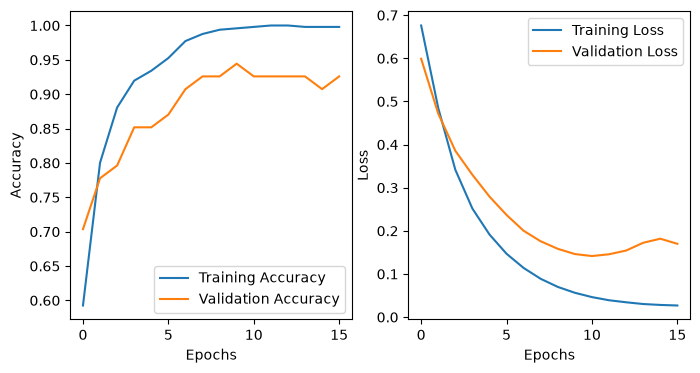

In [7]:
functions.plot_curves(classifier_model_history, epochs=len(classifier_model_history.history['loss']))

Evaluate the model on test data

Accuracy of the model on test data :  0.9
####################################################################################################
              precision    recall  f1-score   support

           0       0.96      0.83      0.89        30
           1       0.85      0.97      0.91        30

    accuracy                           0.90        60
   macro avg       0.91      0.90      0.90        60
weighted avg       0.91      0.90      0.90        60



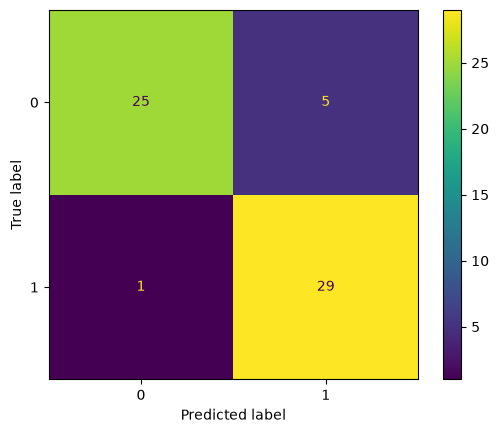

Total Synthetic recordings predicted 26
Total real recordings predicted 34


In [8]:
y_pred = np.rint(classifier_model.predict(X_all[test_idx], verbose=0)).flatten()

functions.eval_results(y_all[test_idx], y_pred)

#### 5-fold cross-validation grouped by speaker
Each fold holds out 20% of speakers for testing; 10% of the remaining speakers are used for early stopping.

In [9]:
results = []
for fold, (train_idx, test_idx) in enumerate(GroupKFold(n_splits=5).split(X_all, y_all, groups)):
    tr_idx, val_idx = speaker_split(train_idx, test_size=0.1, seed=fold)
    model = build_model()
    history = model.fit(X_all[tr_idx], y_all[tr_idx], epochs=1000, verbose=0,
                        validation_data=(X_all[val_idx], y_all[val_idx]),
                        callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)])
    pred = np.rint(model.predict(X_all[test_idx], verbose=0)).flatten()
    results.append({'fold': fold + 1, 'test files': len(test_idx), 'epochs': len(history.history['loss']),
                    'accuracy': accuracy_score(y_all[test_idx], pred), 'f1': f1_score(y_all[test_idx], pred),
                    'errors': int((pred != y_all[test_idx]).sum())})

cv = pd.DataFrame(results)
print(cv.to_string(index=False))
print(f"\nAccuracy: {cv.accuracy.mean():.3f} ± {cv.accuracy.std():.3f}   F1: {cv.f1.mean():.3f} ± {cv.f1.std():.3f}   "
      f"Total errors: {cv.errors.sum()}/{cv['test files'].sum()}")

 fold  test files  epochs  accuracy       f1  errors
    1         120      61  0.991667 0.991597       1
    2         120      36  0.966667 0.965517       4
    3         120     156  0.991667 0.991736       1
    4         120      56  0.950000 0.950000       6
    5         120      23  0.933333 0.936508       8

Accuracy: 0.967 ± 0.026   F1: 0.967 ± 0.025   Total errors: 20/600
